# This notebook is for generating all the scores

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
metrics  = pd.read_csv('metrics_results/mar1_full_results.csv')
ridership_by_date = pd.read_csv('metrics_results/ridership_results.csv')

In [4]:
metrics['bus_trust_score'] = (
    0.45 * metrics['p_otp'] +
    0.25 * metrics['p_severity'] +
    0.20 * metrics['p_reliability'] +
    0.10 * metrics['p_ghost']
)

In [5]:
metrics = metrics[['route_id', 'bus_trust_score']].sort_values(by='bus_trust_score')

In [6]:
ridership_by_date['ridership_score'] = (ridership_by_date.rides - ridership_by_date.rides.min()) / (ridership_by_date.rides.max() - ridership_by_date.rides.min())

In [7]:
metrics = metrics.merge(ridership_by_date, right_on='route', left_on='route_id', how='left')

In [8]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   route_id         123 non-null    object 
 1   bus_trust_score  123 non-null    float64
 2   Unnamed: 0       123 non-null    int64  
 3   route            123 non-null    object 
 4   rides            123 non-null    float64
 5   ridership_score  123 non-null    float64
 6   log_ridership    123 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 6.9+ KB


In [9]:
metrics.head()

,route_id,bus_trust_score,Unnamed: 0,route,rides,ridership_score,log_ridership
0,171,53.913833,36,171,602.758007,0.032795,6.403173
1,N5,54.748333,125,N5,111.350746,0.000803,4.721626
2,62,55.138167,84,62,6658.338323,0.427034,8.803775
3,201,65.856833,43,201,1139.989324,0.067771,7.039651
4,169,66.521667,35,169,99.014493,0.000000,4.605315


(array([ 3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  3.,  2.,  1.,
         7.,  3.,  4.,  8., 10., 14., 14., 12., 10.,  6., 12.,  4.,  2.,
         4.,  2.,  0.,  1.]),
 array([53.91383333, 55.17207778, 56.43032222, 57.68856667, 58.94681111,
        60.20505556, 61.4633    , 62.72154444, 63.97978889, 65.23803333,
        66.49627778, 67.75452222, 69.01276667, 70.27101111, 71.52925556,
        72.7875    , 74.04574444, 75.30398889, 76.56223333, 77.82047778,
        79.07872222, 80.33696667, 81.59521111, 82.85345556, 84.1117    ,
        85.36994444, 86.62818889, 87.88643333, 89.14467778, 90.40292222,
        91.66116667]),
 <BarContainer object of 30 artists>)

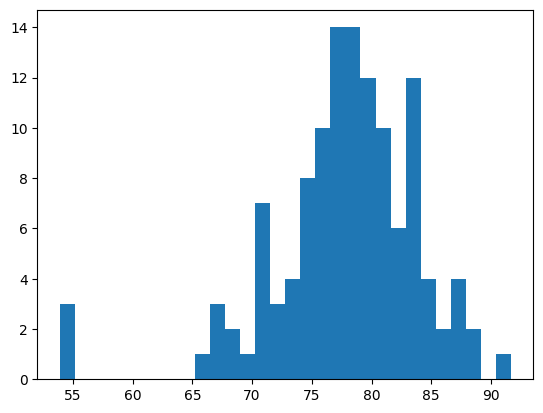

In [10]:
plt.hist(metrics['bus_trust_score'], bins=30)

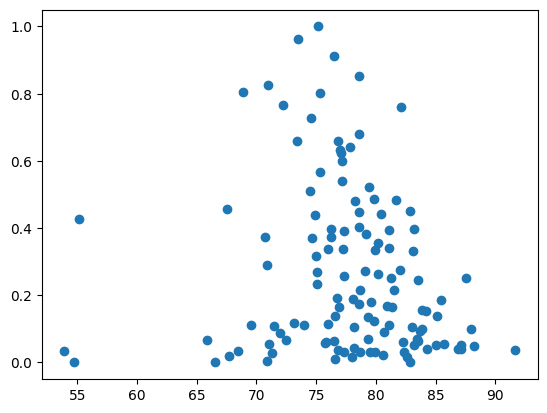

In [11]:
plt.scatter(y=metrics.ridership_score, x=metrics.bus_trust_score)

In [23]:
metrics.sort_values(by='bus_trust_score', ascending=False)

,route_id,bus_trust_score,Unnamed: 0,route,rides,ridership_score,log_ridership
122,43,91.661167,60,43,672.467066,0.037334,6.512439
121,51,88.178500,68,51,844.853293,0.048557,6.740346
120,8A,87.967167,114,8A,1640.976048,0.100387,7.403656
119,75,87.563667,98,75,3968.107784,0.251891,8.286297
118,112,87.129000,10,112,893.700599,0.051737,6.796489
...,...,...,...,...,...,...,...
4,169,66.521667,35,169,99.014493,0.000000,4.605315
3,201,65.856833,43,201,1139.989324,0.067771,7.039651
2,62,55.138167,84,62,6658.338323,0.427034,8.803775
1,N5,54.748333,125,N5,111.350746,0.000803,4.721626


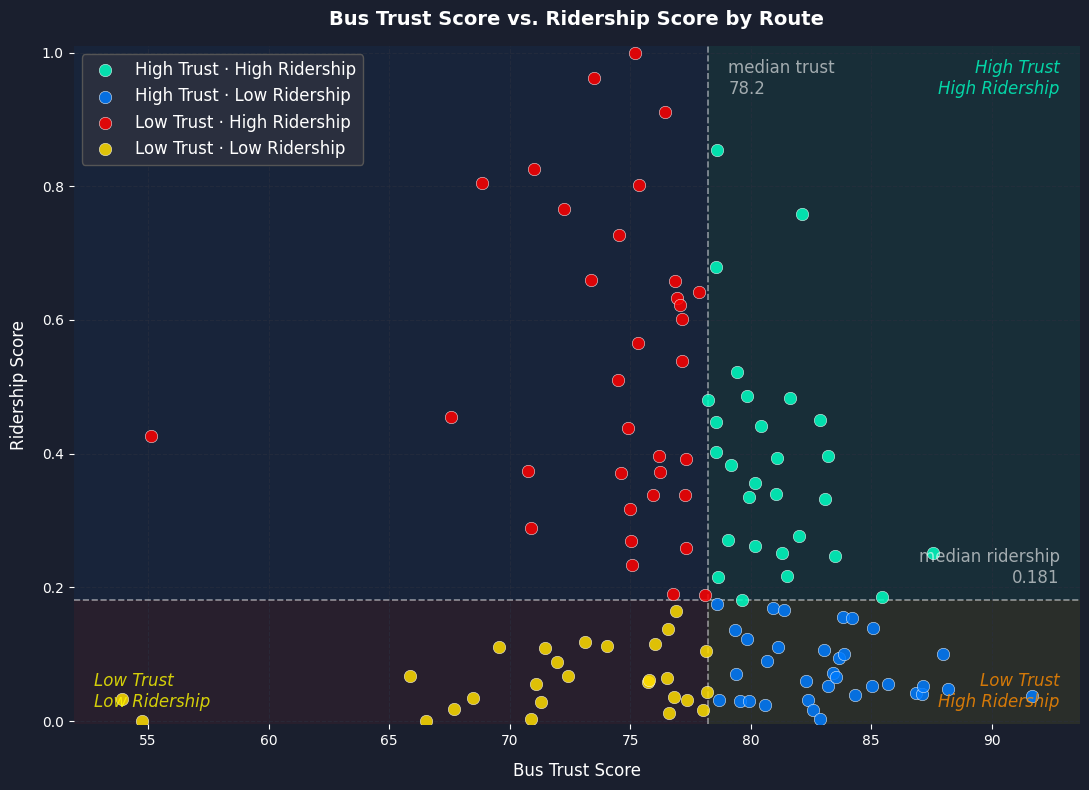

In [21]:
df = metrics.copy()
import matplotlib.patches as mpatches

# ── Quadrant thresholds (medians by default — change if you prefer fixed vals)
trust_mid      = df["bus_trust_score"].median()
ridership_mid  = df["ridership_score"].median()

# ── Quadrant assignment ──────────────────────────────────────────────────────
def assign_quadrant(row):
    hi_trust     = row["bus_trust_score"] >= trust_mid
    hi_ridership = row["ridership_score"] >= ridership_mid
    if hi_trust and hi_ridership:
        return "High Trust\nHigh Ridership"
    elif hi_trust and not hi_ridership:
        return "High Trust\nLow Ridership"
    elif not hi_trust and hi_ridership:
        return "Low Trust\nHigh Ridership"
    else:
        return "Low Trust\nLow Ridership"

df["quadrant"] = df.apply(assign_quadrant, axis=1)

# ── Colors per quadrant ──────────────────────────────────────────────────────
quad_colors = {
    "High Trust\nHigh Ridership":  "#00ffc3",   # teal   – best performers
    "High Trust\nLow Ridership":   "#007bff",   # blue   – trusted but low use
    "Low Trust\nHigh Ridership":   "#ff0000",   # amber  – popular but unreliable
    "Low Trust\nLow Ridership":    "#ffdd00",   # red    – needs attention

}
quad_labels = {
    "High Trust\nHigh Ridership":  "High Trust · High Ridership",
    "High Trust\nLow Ridership":   "High Trust · Low Ridership",
    "Low Trust\nHigh Ridership":   "Low Trust · High Ridership",
    "Low Trust\nLow Ridership":    "Low Trust · Low Ridership",
}

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#1a1f2e",
    "axes.facecolor":   "#1a1f2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#2a2f3e",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
})

fig, ax = plt.subplots(figsize=(11, 8))

for quad, color in quad_colors.items():
    subset = df[df["quadrant"] == quad]
    ax.scatter(
        subset["bus_trust_score"],
        subset["ridership_score"],
        c=color, s=80, alpha=0.85, edgecolors="white", linewidths=0.4,
        label=quad_labels[quad], zorder=3
    )

# ── Quadrant dividers ────────────────────────────────────────────────────────
ax.axvline(trust_mid,     color="white", lw=1.2, linestyle="--", alpha=0.5, zorder=2)
ax.axhline(ridership_mid, color="white", lw=1.2, linestyle="--", alpha=0.5, zorder=2)

# ── Quadrant background shading ──────────────────────────────────────────────
xlim = (df["bus_trust_score"].min() - 2, df["bus_trust_score"].max() + 2)
ylim = (df["ridership_score"].min() - 0.005, df["ridership_score"].max() + 0.01)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

shade_quads = [
    (xlim[0], trust_mid,  ylim[0], ridership_mid, "#e92121", 0.07),   # Low/Low
    (trust_mid, xlim[1],  ylim[0], ridership_mid, "#fffb00", 0.07),   # Low trust hi ridership
    (xlim[0], trust_mid,  ridership_mid, ylim[1], "#0a6ed9", 0.07),   # Hi trust lo ridership
    (trust_mid, xlim[1],  ridership_mid, ylim[1], "#03ffc4", 0.07),   # Hi/Hi
]
for x0, x1, y0, y1, c, a in shade_quads:
    ax.add_patch(mpatches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        facecolor=c, alpha=a, zorder=1
    ))

# ── Quadrant corner labels ───────────────────────────────────────────────────
pad_x = (xlim[1] - xlim[0]) * 0.02
pad_y = (ylim[1] - ylim[0]) * 0.02

corner_labels = [
    (xlim[0] + pad_x, ylim[0] + pad_y, "Low Trust\nLow Ridership",    "#fffb00", "left",  "bottom"),
    (xlim[1] - pad_x, ylim[0] + pad_y, "Low Trust\nHigh Ridership",   "#ff8c00", "right", "bottom"),
    (xlim[0] + pad_x, ylim[1] - pad_y, "High Trust\nLow Ridership",   "#007bff", "left",  "top"),
    (xlim[1] - pad_x, ylim[1] - pad_y, "High Trust\nHigh Ridership",  "#00ffc3", "right", "top"),
]
for cx, cy, text, color, ha, va in corner_labels:
    ax.text(cx, cy, text, color=color, fontsize=12, alpha=0.8,
            ha=ha, va=va, fontstyle="italic", zorder=4)

# ── Median crosshair labels ──────────────────────────────────────────────────
ax.text(trust_mid + pad_x, ylim[1] - pad_y,
        f"median trust\n{trust_mid:.1f}",
        color="white", fontsize=12, alpha=0.6, ha="left", va="top")
ax.text(xlim[1] - pad_x, ridership_mid + pad_y,
        f"median ridership\n{ridership_mid:.3f}",
        color="white", fontsize=12, alpha=0.6, ha="right", va="bottom")

# ── Optional: label individual route points ──────────────────────────────────
# Uncomment to annotate route IDs (can get crowded with many routes)
# for _, row in df.iterrows():
#     ax.text(row["bus_trust_score"] + 0.1, row["ridership_score"],
#             row["route_id"], fontsize=6, color="white", alpha=0.6)

# ── Axes labels, title, legend ───────────────────────────────────────────────
ax.set_xlabel("Bus Trust Score", fontsize=12, labelpad=10)
ax.set_ylabel("Ridership Score", fontsize=12, labelpad=10)
ax.set_title("Bus Trust Score vs. Ridership Score by Route",
             fontsize=14, pad=15, fontweight="bold")

legend = ax.legend(loc="upper left", fontsize=12,
                   facecolor="#2a2f3e", edgecolor="#555",
                   labelcolor="white", framealpha=1)

ax.grid(True)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()


In [24]:
metrics.to_csv('metrics_results/final_metrics_dataset.csv')